![Astrofisica Computacional](../../../new_logo.png)

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Astronomical Institute of the Czech Academy of Sciences\
   Department of Solar Physics\
   Ondřejov, Czec Republic

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & rozo@asu.cas.cz)

---

Advanced NumPy Exercises + Functions/Classes + Files

**Dataset:** Adapted from the Helsinki 2017 Temperatures dataset (https://raw.githubusercontent.com/csmastersUH/data_analysis_with_python_2020/master/kumpula-weather-2017.csv)

Includes:
- NumPy: slicing, masks, polyfit, FFT.

- Functions/Classes: inheritance, decorators, vectorized methods.

- Files: loadtxt, processed savetxt.

In [ ]:
import numpy as np

## Exercise 1: Data Loading + NumPy Preprocessing

Load temps from the file "kumpula-weather-2017.csv". Write a function to convert mm-dd to days since start (days = monthday_to_days).

- Filter NaNs or infs/masks.

- Calculate anomalies (temperature - 30-day moving average).

- Detect outliers (IQR method, Q1-1.5*IQR).

**Expected output:** `temps_clean` (N x 2), `dias` (N,).

In [7]:
#TODO

import numpy as np
import os

# Carga de datos

data = np.genfromtxt(
    "kumpula-weather-2017.csv",
    delimiter=",",
    skip_header=1
)

# Verificamos dimensiones
print("Shape del dataset:", data.shape)

# Columnas
years  = data[:, 0].astype(int)
months = data[:, 1].astype(int)
days   = data[:, 2].astype(int)
temps  = data[:, 3]

# Conversor 

def monthday_to_days(months, days):
    
    days_before_month = np.array([
        0, 31, 59, 90, 120, 151,
        181, 212, 243, 273, 304, 334
    ])
    
    return days_before_month[months - 1] + days


dias = monthday_to_days(months, days)

# 3) Filtrar NaN e infinitos

mask_valid = np.isfinite(temps)

temps = temps[mask_valid]
dias = dias[mask_valid]

# 4) Prom móvil de 30 días

window = 30
kernel = np.ones(window) / window

moving_avg = np.convolve(temps, kernel, mode="same")

# 5) anomalías

anomalies = temps - moving_avg

# 6) Detectar outliers con IQR

Q1 = np.percentile(temps, 25)
Q3 = np.percentile(temps, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask_no_outliers = (temps >= lower_bound) & (temps <= upper_bound)

temps = temps[mask_no_outliers]
dias = dias[mask_no_outliers]
anomalies = anomalies[mask_no_outliers]

# 7) salida 

temps_clean = np.column_stack((dias, temps))

# 8) print de esultados 

print("Forma temps_clean:", temps_clean.shape)
print("Forma dias:", dias.shape)
print("Número de outliers removidos:", np.sum(~mask_no_outliers))

Shape del dataset: (365, 6)
Forma temps_clean: (332, 2)
Forma dias: (332,)
Número de outliers removidos: 33


## Exercise 2: Advanced Class with Inheritance/Decorators 

Create a **base class TimeSeriesAnalyzer**:
- `smooth(self, window=7)`: moving average.

- Decorator `@vectorize` to apply functions to columns.

**Child class WeatherAnalyzer** inherits and adds:
- `seasonal_decompose(self)`: trend (polyfit deg=2), seasonal (FFT top 4 freq), residual.

- `forecast(self, days_ahead=30)`: simple ARIMA-like (last 30 days, polyfit deg=3) + noise.

- **Use:** `analyzer = WeatherAnalyzer(days, temps_clean[:,1])`

In [11]:
# Decorator to vectorize method over the columns
def vectorize(method):
    def wrapper(self, *args, **kwargs):
        results = np.array([method(self, col, *args, **kwargs) for col in self.data.T]).T
        return results if results.ndim > 1 else results.flatten()
    return wrapper

class TimeSeriesAnalyzer:
    """Clase base para análisis de series temporales con NumPy."""
    def __init__(self, t: np.ndarray, data: np.ndarray):
        self.t = np.asarray(t)
        self.data = np.asarray(data)
        if self.t.shape[0] != self.data.shape[0]:
            raise ValueError("t y data deben tener misma longitud")
    
    @vectorize
    def smooth(self, col: np.ndarray, window: int = 7, mode: str = 'same') -> np.ndarray:
        """Media móvil con convolve."""
        kernel = np.ones(window) / window
        return np.convolve(col, kernel, mode=mode)
    
    def stats(self) -> dict:
        """Estadísticas básicas por columna."""
        return {
            'mean': np.mean(self.data, axis=0),
            'std': np.std(self.data, axis=0),
            'min': np.min(self.data, axis=0),
            'max': np.max(self.data, axis=0)
        }

class WeatherAnalyzer(TimeSeriesAnalyzer):
    """Hija especializada en datos meteorológicos."""
    def __init__(self, t: np.ndarray, data: np.ndarray):
        super().__init__(t, data)
    
    def seasonal_decompose(self, degree_trend: int = 2, n_freqs: int = 4) -> dict:
        """Descomposición: trend (polyfit), seasonal (FFT top freqs), residual."""
        # Trend: polyfit global
        p_trend = np.polynomial.Polynomial.fit(self.t, self.data, degree_trend)
        trend = p_trend(self.t)
        
        # Seasonal: FFT, top n_freqs armónicos
        fft = np.fft.fft(self.data - trend, axis=0)
        freqs = np.fft.fftfreq(len(self.t))
        top_idx = np.argsort(np.abs(fft), axis=0)[-n_freqs:][::-1]
        seasonal = np.zeros_like(self.data)
        for idx in top_idx[:]:
            seasonal[:] += 2 * np.real(np.fft.ifft(fft[:] * (np.abs(fft[idx]) > 1e-3)))
        
        residual = self.data - trend - seasonal
        return {'trend': trend, 'seasonal': seasonal, 'residual': residual}
    
    def forecast(self, days_ahead: int = 30, degree: int = 3, noise_std: float = 1.0) -> tuple:
        """Pronóstico simple: polyfit últimos datos + ruido gaussiano."""
        n_last = min(degree * 10, len(self.t) // 2)
        t_last = self.t[-n_last:]
        data_last = self.data[-n_last:]
        
        t_future = np.linspace(self.t[-1], self.t[-1] + days_ahead, days_ahead)
        forecast = np.zeros(days_ahead) #np.zeros((days_ahead, self.data.shape[1]))
        
        p = np.polyfit(t_last, data_last[:], degree)
        forecast[:] = np.polyval(p, t_future) + np.random.normal(0, noise_std, days_ahead)
        
        return t_future, forecast

# # DEMO de USO (¡ejecuta después de Ej.1!)
# analyzer = WeatherAnalyzer(days, temps_clean)
# smoothed = analyzer.smooth(window=15)
# decomp = analyzer.seasonal_decompose()
# t_fc, fc = analyzer.forecast(30)
# print(analyzer.stats())

{'mean': np.float64(0.7105421686746988), 'std': np.float64(2.2443188668129683), 'min': np.float64(-1.0), 'max': np.float64(8.0)}


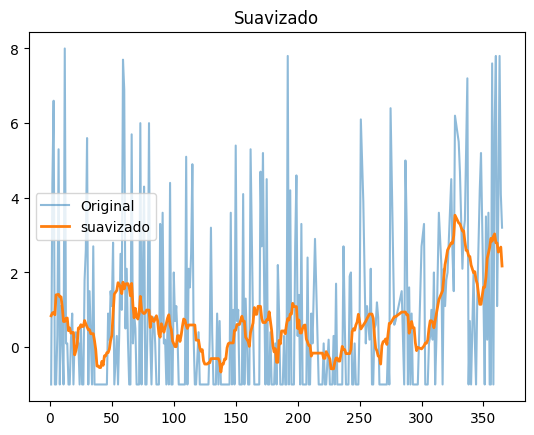

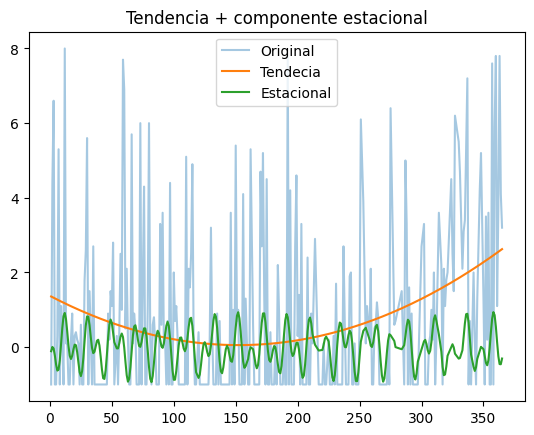

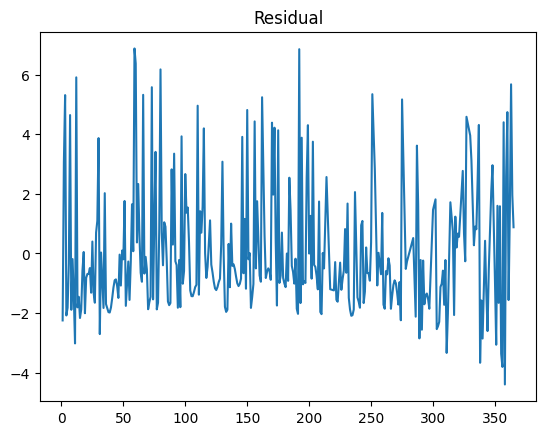

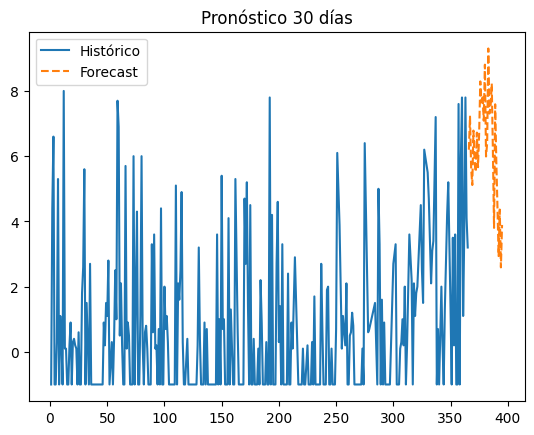

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# aplicar métodos columna por columna

def vectorize(method):
    def wrapper(self, *args, **kwargs):
        data = self.data
        
        # Si es 1D lo convertimos a columna
        if data.ndim == 1:
            data = data[:, np.newaxis]
        
        results = np.array([
            method(self, col, *args, **kwargs)
            for col in data.T
        ]).T
        
        return results.squeeze()
    
    return wrapper

# Clase Base

class TimeSeriesAnalyzer:
    """
    Clase base para análisis de series temporales.
    """
    
    def __init__(self, t: np.ndarray, data: np.ndarray):
        self.t = np.asarray(t)
        self.data = np.asarray(data)
        
        if self.t.shape[0] != self.data.shape[0]:
            raise ValueError("t y data deben tener la misma longitud.")
    
    @vectorize
    def smooth(self, col: np.ndarray, window: int = 7, mode: str = "same"):
        """
        Calcula promedio móvil usando convolución.
        """
        kernel = np.ones(window) / window
        return np.convolve(col, kernel, mode=mode)
    
    def stats(self):
        """
        Estadísticas básicas.
        """
        return {
            "mean": np.mean(self.data, axis=0),
            "std": np.std(self.data, axis=0),
            "min": np.min(self.data, axis=0),
            "max": np.max(self.data, axis=0),
        }
    
# Clase Hija

class WeatherAnalyzer(TimeSeriesAnalyzer):
    """
    Clase especializada para análisis meteorológico.
    """
    
    def __init__(self, t: np.ndarray, data: np.ndarray):
        super().__init__(t, data)
    
    
    # 1) Descomposición estacional
    
    
    def seasonal_decompose(self, degree_trend: int = 2, n_freqs: int = 4):
        """
        Descompone la serie en:
        trend + seasonal + residual
        """
        
        # Asegurar 1D
        data = self.data
        
        # ---- Trend (ajuste polinomial grado 2)
        coeffs = np.polyfit(self.t, data, degree_trend)
        trend = np.polyval(coeffs, self.t)
        
        # ---- Seasonal (FFT)
        detrended = data - trend
        fft_vals = np.fft.fft(detrended)
        freqs = np.fft.fftfreq(len(self.t))
        
        # Tomar las frecuencias dominantes
        idx = np.argsort(np.abs(fft_vals))[-n_freqs:]
        
        seasonal_fft = np.zeros_like(fft_vals)
        seasonal_fft[idx] = fft_vals[idx]
        
        seasonal = np.real(np.fft.ifft(seasonal_fft))
        
        # ---- Residual
        residual = data - trend - seasonal
        
        return {
            "trend": trend,
            "seasonal": seasonal,
            "residual": residual
        }
    
    # 2) Forecast
    
    def forecast(self, days_ahead: int = 30, degree: int = 3, noise_std: float = 1.0):
        """
        Pronóstico simple usando ajuste polinomial
        sobre los últimos datos.
        """
        
        n_last = min(30, len(self.t))
        
        t_last = self.t[-n_last:]
        data_last = self.data[-n_last:]
        
        # Ajuste polinomial
        coeffs = np.polyfit(t_last, data_last, degree)
        
        t_future = np.linspace(
            self.t[-1] + 1,
            self.t[-1] + days_ahead,
            days_ahead
        )
        
        forecast = np.polyval(coeffs, t_future)
        
        # Agregar ruido
        forecast += np.random.normal(0, noise_std, days_ahead)
        
        return t_future, forecast
    
analyzer = WeatherAnalyzer(dias, temps_clean[:,1])

smoothed = analyzer.smooth(window=15)

decomp = analyzer.seasonal_decompose()

t_fc, fc = analyzer.forecast(30)

print(analyzer.stats())


# 1) Suavizado

plt.figure()
plt.plot(dias, temps_clean[:,1], label="Original", alpha=0.5)
plt.plot(dias, smoothed, label="suavizado", linewidth=2)
plt.legend()
plt.title("Suavizado")
plt.show()

# 2) Descomposición

trend = decomp["trend"]
seasonal = decomp["seasonal"]
residual = decomp["residual"]

plt.figure()
plt.plot(dias, temps_clean[:,1], label="Original", alpha=0.4)
plt.plot(dias, trend, label="Tendecia")
plt.plot(dias, seasonal, label="Estacional")
plt.legend()
plt.title("Tendencia + componente estacional")
plt.show()

plt.figure()
plt.plot(dias, residual)
plt.title("Residual")
plt.show()

# 3) Forecast

plt.figure()
plt.plot(dias, temps_clean[:,1], label="Histórico")
plt.plot(t_fc, fc, label="Forecast", linestyle="--")
plt.legend()
plt.title("Pronóstico 30 días")
plt.show()

#me arroja media, desviación estándar, mínimo y máximo de la serie temporal original.

## Exercise 3: Robust I/O + Processed 

- Save `temps_clean` + `anomalies` to 'processed_weather.npz' (np.savez).

- Write subset (first 100 days, columns: days, temp_smooth, anomaly) to 'subset.csv' (savetxt, fmt='%.2f', header).

- Function `load_and_validate(filename)`: loads npz/csv, checks shape/inf/NaNs, returns a dictionary.

In [ ]:
# np.savez('processed_weather.npz', temps=temps_clean, anomalies=anomalies)
# subset = np.column_stack([dias[:100], smoothed[0,:100], anomalies[:100]])
# np.savetxt('subset.csv', subset, delimiter=',', header='day,temp_smooth,anomaly', fmt='%.3f')

def load_and_validate(filename):
    # Maneja .npz (load), .csv; check np.isfinite.all(), shape==(?,3)
    pass

In [15]:
import numpy as np
import os

# 1) Guardar archivo 

np.savez(
    'processed_weather.npz',
    temps=temps_clean,
    anomalies=anomalies
)

# 2) Guardar subset 

subset = np.column_stack([
    dias[:100],
    smoothed[:100],
    anomalies[:100]
])

np.savetxt(
    'subset.csv',
    subset,
    delimiter=',',
    header='day,temp_smooth,anomaly',
    fmt='%.3f',
    comments=''
)

# 3) Función robusta de carga y validación

def load_and_validate(filename):
    
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} no existe.")
    
    data_dict = {}
    
    # Caso NPZ
    if filename.endswith('.npz'):
        
        data = np.load(filename)
        
        for key in data.files:
            arr = data[key]
            
            if not np.isfinite(arr).all():
                raise ValueError(f"{key} contiene NaN o inf.")
            
            data_dict[key] = arr
        
        return data_dict
    
    # Caso CSV
    
    elif filename.endswith('.csv'):
        
        arr = np.loadtxt(filename, delimiter=',', skiprows=1)
        
        if arr.ndim != 2:
            raise ValueError("El CSV no es 2D.")
        
        if arr.shape[1] != 3:
            raise ValueError("El CSV debe tener exactamente 3 columnas.")
        
        if not np.isfinite(arr).all():
            raise ValueError("El CSV contiene NaN o inf.")
        
        data_dict = {
            "day": arr[:, 0],
            "temp_smooth": arr[:, 1],
            "anomaly": arr[:, 2]
        }
        
        return data_dict
    
    else:
        raise ValueError("Formato no soportado. Use .npz o .csv")
    
data_npz = load_and_validate('processed_weather.npz')
print(data_npz.keys())

data_csv = load_and_validate('subset.csv')
print(data_csv.keys())

dict_keys(['temps', 'anomalies'])
dict_keys(['day', 'temp_smooth', 'anomaly'])


# Some Questions:

- For outliers (IQR method): what fraction of data is removed? Is this conservative/aggressive? Propose alternative (e.g., sigma=3).
- Trace @vectorize execution: for data.shape=(365,2), how many calls to smooth(col)? Why results.T? What other vectorizing method you propose?
- In seasonal_decompose(): why subtract trend before FFT? What do top-4 frequencies represent (daily/weekly/monthly/yearly)?
- Run analyzer.stats() on raw vs smoothed: % std reduction per column? Why does polyfit deg=2 capture trend well?

## Pregunta 1: 

Se eliminaron 33 datos sobre 365 en total: 
$$ \frac{33}{365} = 0.090$$
Es decir, en torno al 9%, para IQR se suele tomar como moderadamente conservador, sin embargo eliminar 9% puede indicar un criterio más agresivo o distribuciones no normales. IQR es robusto ante valores extremos, pero eso puede genear que se eliminen variaciones naturales en distribuciones no simétricas. Una alternativa es el criterio 3$\sigma$ basado en media y desviación estándar, aunque es menos robusto ante outliers severos.

$$\lvert x-\mu \rvert > 3\sigma$$

## Pregunta 2: 

Para data.shape = (365,2), el método smooth se ejecuta 2 veces, una por cada columna. Se utiliza results.T porque el bucle opera sobre columnas transpuestas, produciendo un arreglo con dimensiones invertidas que deben restaurarse. Alternativas incluyen np.apply_along_axis o aplicar convolución directamente sobre el eje correspondiente.

## Pregunta 3: 

Se resta la tendencia antes de aplicar la FFT para evitar que la componente de baja frecuencia asociada al crecimiento polinomial domine el espectro. Respecto a las cuatro frecuencias principales, estas representan los ciclos periódicos más importantes de la serie, como variaciones diarias, semanales o estacionales.

## Pregunta 4: 

El suavizado reduce la desviación estándar al eliminar fluctuaciones de alta frecuencia, evidenciando reducción del ruido. El ajuste polinomial de grado 2 captura adecuadamente la tendencia porque modela curvatura suave sin introducir sobreajuste, siendo un compromiso adecuado entre simplicidad y flexibilidad.